In [1]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns


import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))

PyTorch version: 2.8.0+cu128
CUDA available: True
Number of GPUs: 1
Current GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')
subm = pd.read_csv('./sample_submission.csv')


Epoch 1/5 - Loss: 0.5122 - Val AUC: 0.9826
Epoch 2/5 - Loss: 0.2732 - Val AUC: 0.9857
Epoch 3/5 - Loss: 0.1933 - Val AUC: 0.9845
Epoch 4/5 - Loss: 0.1355 - Val AUC: 0.9840
Epoch 5/5 - Loss: 0.1090 - Val AUC: 0.9830
Submission file saved!


In [3]:
test

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.
...,...,...
153159,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu..."
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...
153161,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ..."
153162,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the..."


In [4]:
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
y = train[list_classes].values
list_sentences_train = train["comment_text"].fillna('').astype(str).tolist()
list_sentences_test = test["comment_text"].fillna('').astype(str).tolist()


# BiLSTM with  Attention

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import re
import random

# ===========================
# 1️⃣ Fix seeds for reproducibility
# ===========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ===========================
# 2️⃣ Load data
# ===========================
train = pd.read_csv('./train_clean.csv')
test = pd.read_csv('./test_clean.csv')
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

y = train[list_classes].values
list_sentences_train = train["comment_text"].fillna("").values
list_sentences_test = test["comment_text"].fillna("").values

# ===========================
# 3️⃣ Simple PyTorch tokenizer
# ===========================
max_features = 20000
maxlen = 200

# Build vocabulary
def simple_tokenizer(sentences, max_features):
    word_count = {}
    for text in sentences:
        for word in re.findall(r'\w+', text.lower()):
            word_count[word] = word_count.get(word, 0) + 1
    vocab = sorted(word_count, key=word_count.get, reverse=True)[:max_features-2]
    word2idx = {word: idx+2 for idx, word in enumerate(vocab)}
    word2idx["<PAD>"] = 0
    word2idx["<UNK>"] = 1
    return word2idx

word2idx = simple_tokenizer(list_sentences_train, max_features)


def encode_sentences(sentences, word2idx, maxlen):
    sequences = []
    for text in sentences:
        # seq = [word2idx.get(w, 1) for w in re.findall(r'\w+', text.lower())]
        seq = [word2idx.get(w, 0) for w in re.findall(r'\w+', text.lower())]  # unknown -> PAD
        if len(seq) < maxlen:
            seq = seq + [0]*(maxlen-len(seq))
        else:
            seq = seq[:maxlen]
        sequences.append(seq)
    return np.array(sequences)

X_t = encode_sentences(list_sentences_train, word2idx, maxlen)
X_te = encode_sentences(list_sentences_test, word2idx, maxlen)


from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_t, y, test_size=0.1, random_state=42
)


# ===========================
# 4️⃣ Dataset & DataLoader
# ===========================
class CommentDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        else:
            return self.X[idx]

train_dataset = CommentDataset(X_train, y_train)
val_dataset = CommentDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)


test_dataset = CommentDataset(X_te)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ===========================
# 5️⃣Bi LSTM Model
# ===========================

    
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_size):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        
        self.lstm = nn.LSTM(
            embed_size,
            128,
            batch_first=True,
            bidirectional=True
        )
        
        # Attention layer
        self.attention = nn.Linear(256, 1)  # 64*2
        
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(256*2, 6)

    def forward(self, x):
        x = self.embedding(x)                       # (B, T, E)
        x, _ = self.lstm(x)                         # (B, T, 128)

        # 🔥 Attention
        attn_weights = torch.softmax(self.attention(x), dim=1)
        attn_out = torch.sum(attn_weights * x, dim=1)

        max_pool, _ = torch.max(x, 1)

        x = torch.cat((attn_out, max_pool), 1)

        x = self.dropout(x)
        x = self.fc(x)  # ⚠️ NO sigmoid here

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = LSTMBaseline(vocab_size=len(word2idx), embed_size=300, maxlen=maxlen).to(device)
model = BiLSTMAttention(vocab_size=len(word2idx), embed_size=300).to(device)
nn.init.uniform_(model.embedding.weight, -0.05, 0.05)

for names in model.lstm._all_weights:
    for name in names:
        if 'bias' in name:
            bias = getattr(model.lstm, name)
            n = bias.size(0)
            # forget gate is the 2nd quarter
            bias.data[n//4:n//2].fill_(1.0)
# ===========================
# 6️⃣ Loss & Optimizer
# ===========================
# criterion = nn.BCEWithLogitsLoss()
pos_weights = torch.tensor(
    (len(y) - y.sum(axis=0)) / y.sum(axis=0),
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)


from sklearn.metrics import roc_auc_score

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)

            preds.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(yb.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    return roc_auc_score(targets, preds, average='macro')


# ===========================
# 7️⃣ Training
# ===========================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=1, factor=0.5
)
epochs = 5
best_auc = 0
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        # loss.backward()
        # optimizer.step()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)

        # ✅ ADD THIS LINE
    val_auc = evaluate(model, val_loader)
    scheduler.step(val_auc)


    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_model.pt")
        
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f} - Val AUC: {val_auc:.4f}")

# ===========================
# 8️⃣ Predict & save submission
# ===========================
model.eval()
model.load_state_dict(torch.load("best_model.pt"))
preds = []
with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        preds.append(torch.sigmoid(model(xb)).cpu())
y_test_pred = torch.cat(preds, dim=0).numpy()

submission = pd.DataFrame({'id': test['id']})
submission[list_classes] = y_test_pred
submission.to_csv('submission_BiLSTM_pytorch.csv', index=False)
print("Submission file saved!")

# LSTM baseline: GloVe + dropout

In [ ]:
# =========================================
# 1. IMPORTS
# =========================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
from collections import defaultdict

# =========================================
# 2. PARAMETERS
# =========================================
embed_size = 100       # embedding vector size
max_features = 20000  # max vocabulary size
maxlen = 100          # max words per comment
hidden_size = 64      # LSTM hidden size
batch_size = 32
epochs = 10
dropout = 0.1
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# =========================================
# 3. PREPARE TEXT DATA
# =========================================
# Fill missing values and convert to list
list_sentences_train = train["comment_text"].fillna("_na_").astype(str).tolist()
list_sentences_test  = test["comment_text"].fillna("_na_").astype(str).tolist()

y = train[list_classes].values.astype(np.float32)

# =========================================
# 4. TOKENIZE TEXT (build vocabulary)
# =========================================
# Simple tokenizer: word → index
word_freq = defaultdict(int)
for sent in list_sentences_train:
    for w in sent.split():
        word_freq[w] += 1

# Sort by frequency and keep top max_features
vocab = sorted(word_freq, key=word_freq.get, reverse=True)[:max_features]
word_to_idx = {w: i+1 for i, w in enumerate(vocab)}  # 0 is reserved for padding
vocab_size = len(word_to_idx) + 1

def texts_to_sequences(texts):
    sequences = []
    for sent in texts:
        seq = [word_to_idx.get(w, 0) for w in sent.lower().split()]
        seq = seq[:maxlen] + [0]*(maxlen - len(seq))
        sequences.append(torch.tensor(seq, dtype=torch.long))
    return torch.stack(sequences)

X_train = texts_to_sequences(list_sentences_train)
X_test  = texts_to_sequences(list_sentences_test)
y_train = torch.tensor(y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Labels shape:", y_train.shape)

# =========================================
# 5. LOAD PRETRAINED EMBEDDINGS (example: GloVe)
# =========================================
EMBEDDING_FILE = "./glove.6B.100d.txt"  # download 50d GloVe
def get_coefs(word, *arr): 
    return word, np.asarray(arr, dtype=np.float32)

embeddings_index = {}
with open(EMBEDDING_FILE, encoding='utf8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]

        # ✅ ONLY keep words in your vocab
        if word in word_to_idx:
            embeddings_index[word] = np.asarray(values[1:], dtype=np.float32)

# Mean/std for random initialization of unknown words
all_embs = np.stack([v for v in embeddings_index.values() if v is not None])
emb_mean, emb_std = all_embs.mean(), all_embs.std()

# Build embedding matrix
embedding_matrix = np.random.normal(emb_mean, emb_std, (vocab_size, embed_size)).astype(np.float32)
for word, i in word_to_idx.items():
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

embedding_matrix = torch.tensor(embedding_matrix)

# =========================================
# 6. CREATE PYTORCH DATASET
# =========================================
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# =========================================
# 7. MODEL DEFINITION
# =========================================
class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, num_classes, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, bidirectional=True, num_layers=2, dropout=0.2)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(hidden_size*2, 50)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(50, num_classes)
        # self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)                  # (batch, seq_len, embed_size)
        x, _ = self.lstm(x)                    # (batch, seq_len, hidden*2)
        x = x.permute(0, 2, 1)                 # for max pooling: (batch, hidden*2, seq_len)
        x = self.pool(x).squeeze(-1)           # (batch, hidden*2)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        # return self.sigmoid(x)
        return x

model = LSTMClassifier(embedding_matrix, hidden_size, len(list_classes), dropout)
# criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# =========================================
# 8. TRAINING LOOP
# =========================================
for epoch in range(epochs):
    model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# =========================================
# 9. PREDICTION
# =========================================
model.eval()
print("training finished.")
test_loader = DataLoader(X_test, batch_size=256)  # small batches

preds = []
with torch.no_grad():
    for i, xb in enumerate(test_loader):
        if i % 100 == 0:
            print(f"Predicting batch {i}/{len(test_loader)}")
        
        # preds.append(model(xb))
        preds.append(torch.sigmoid(model(xb)))

# Combine all batches
y_test_pred = torch.cat(preds, dim=0)

print("Prediction done:", y_test_pred.shape)



# Convert to numpy
y_test_pred = y_test_pred.cpu().numpy()

# Create submission dataframe
submission = pd.DataFrame({
    'id': test['id']
})

# Add predictions (6 columns)
submission[list_classes] = y_test_pred

# Save
submission.to_csv('submission_lstm.csv', index=False)

print("Submission file saved!")

Train shape: torch.Size([159571, 100])
Test shape: torch.Size([153164, 100])
Labels shape: torch.Size([159571, 6])
Epoch 1, Loss: 0.0169
Epoch 2, Loss: 0.0170
Epoch 3, Loss: 0.0366
Epoch 4, Loss: 0.0129
Epoch 5, Loss: 0.0263
Epoch 6, Loss: 0.0209
Epoch 7, Loss: 0.0034
Epoch 8, Loss: 0.0182
Epoch 9, Loss: 0.0054
Epoch 10, Loss: 0.0212
training finished.
Predicting batch 0/599
Predicting batch 100/599
Predicting batch 200/599
Predicting batch 300/599
Predicting batch 400/599
Predicting batch 500/599
Prediction done: torch.Size([153164, 6])
Submission file saved!


torch.Size([159571, 100]) torch.Size([159571, 6])


Loaded embeddings: 12475


# GRU + attention

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
from collections import defaultdict



list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

y = train[list_classes].values.astype(np.float32)

train_texts = train["comment_text"].fillna('').astype(str).tolist()
test_texts  = test["comment_text"].fillna('').astype(str).tolist()

max_features = 20000
maxlen = 100

word_freq = defaultdict(int)

for sent in train_texts:
    for w in sent.lower().split():
        word_freq[w] += 1

vocab = sorted(word_freq, key=word_freq.get, reverse=True)[:max_features]
word_to_idx = {w: i+1 for i, w in enumerate(vocab)}  # 0 = padding

vocab_size = len(word_to_idx) + 1

def texts_to_sequences(texts):
    sequences = []
    for sent in texts:
        seq = [word_to_idx.get(w, 0) for w in sent.lower().split()]
        seq = seq[:maxlen] + [0]*(maxlen - len(seq))
        sequences.append(seq)
    return torch.tensor(sequences, dtype=torch.long)

X_train = texts_to_sequences(train_texts)
X_test  = texts_to_sequences(test_texts)
y_train = torch.tensor(y)

print(X_train.shape, y_train.shape)


embed_size = 100
EMBEDDING_FILE = "./glove.6B.100d.txt"

embeddings_index = {}

with open(EMBEDDING_FILE, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]

        if word in word_to_idx:
            embeddings_index[word] = np.asarray(values[1:], dtype=np.float32)

print("Loaded embeddings:", len(embeddings_index))

embedding_matrix = np.zeros((vocab_size, embed_size), dtype=np.float32)

for word, i in word_to_idx.items():
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

embedding_matrix = torch.tensor(embedding_matrix)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

dataset = TensorDataset(X_train, y_train)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)


class GRUAttentionModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, num_classes):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False
        )

        self.gru = nn.GRU(
            embed_size,
            hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.attention = Attention(hidden_size)

        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.gru(x)
        x = self.attention(x)
        return self.fc(x)
    
model = GRUAttentionModel(
    embedding_matrix,
    hidden_size=64,
    num_classes=len(list_classes)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")


test_loader = DataLoader(X_test, batch_size=512)

model.eval()
preds = []

with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        preds.append(torch.sigmoid(model(xb)).cpu())

y_test_pred = torch.cat(preds).numpy()

submission = pd.DataFrame({'id': test['id']})
submission[list_classes] = y_test_pred
submission.to_csv('submission_gru_attn.csv', index=False)

print("✅ Submission saved!")

torch.Size([159571, 100]) torch.Size([159571, 6])
Loaded embeddings: 12475
Using: cuda
Epoch 1, Loss: 0.0760
Epoch 2, Loss: 0.0491
Epoch 3, Loss: 0.0437
Epoch 4, Loss: 0.0390
Epoch 5, Loss: 0.0344
Epoch 6, Loss: 0.0304
Epoch 7, Loss: 0.0266
Epoch 8, Loss: 0.0231
Epoch 9, Loss: 0.0199
Epoch 10, Loss: 0.0169
✅ Submission saved!


In [18]:
# =========================================
# 1. IMPORTS
# =========================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
from collections import defaultdict

# =========================================
# 2. PARAMETERS
# =========================================
embed_size = 100       # embedding vector size
max_features = 20000  # max vocabulary size
maxlen = 100          # max words per comment
hidden_size = 64      # LSTM hidden size
batch_size = 32
epochs = 10
dropout = 0.1
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# =========================================
# 3. PREPARE TEXT DATA
# =========================================
# Fill missing values and convert to list
list_sentences_train = train["comment_text"].fillna("_na_").astype(str).tolist()
list_sentences_test  = test["comment_text"].fillna("_na_").astype(str).tolist()

y = train[list_classes].values.astype(np.float32)

# =========================================
# 4. TOKENIZE TEXT (build vocabulary)
# =========================================
# Simple tokenizer: word → index
word_freq = defaultdict(int)
for sent in list_sentences_train:
    for w in sent.split():
        word_freq[w] += 1

# Sort by frequency and keep top max_features
vocab = sorted(word_freq, key=word_freq.get, reverse=True)[:max_features]
word_to_idx = {w: i+1 for i, w in enumerate(vocab)}  # 0 is reserved for padding
vocab_size = len(word_to_idx) + 1

def texts_to_sequences(texts):
    sequences = []
    for sent in texts:
        seq = [word_to_idx.get(w, 0) for w in sent.lower().split()]
        seq = seq[:maxlen] + [0]*(maxlen - len(seq))
        sequences.append(torch.tensor(seq, dtype=torch.long))
    return torch.stack(sequences)

X_train = texts_to_sequences(list_sentences_train)
X_test  = texts_to_sequences(list_sentences_test)
y_train = torch.tensor(y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Labels shape:", y_train.shape)

# =========================================
# 5. CREATE PYTORCH DATASET
# =========================================
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# =========================================
# 6. MODEL DEFINITION (baseline embeddings)
# =========================================
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)  # randomly initialized
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, bidirectional=True, 
                            num_layers=2, dropout=0.2)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(hidden_size*2, 50)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(50, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)                  # (batch, seq_len, embed_size)
        x, _ = self.lstm(x)                    # (batch, seq_len, hidden*2)
        x = x.permute(0, 2, 1)                 # for max pooling: (batch, hidden*2, seq_len)
        x = self.pool(x).squeeze(-1)           # (batch, hidden*2)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = LSTMClassifier(vocab_size, embed_size, hidden_size, len(list_classes), dropout)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# =========================================
# 7. TRAINING LOOP
# =========================================
for epoch in range(epochs):
    model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# =========================================
# 8. PREDICTION
# =========================================
model.eval()
print("Training finished.")
test_loader = DataLoader(X_test, batch_size=256)

preds = []
with torch.no_grad():
    for xb in test_loader:
        preds.append(torch.sigmoid(model(xb)))

y_test_pred = torch.cat(preds, dim=0).cpu().numpy()

# =========================================
# 9. SUBMISSION
# =========================================
submission = pd.DataFrame({'id': test['id']})
submission[list_classes] = y_test_pred
submission.to_csv('submission_lstm_baseline.csv', index=False)
print("Submission file saved!")

Train shape: torch.Size([159571, 100])
Test shape: torch.Size([153164, 100])
Labels shape: torch.Size([159571, 6])
Epoch 1, Loss: 0.0295
Epoch 2, Loss: 0.1168
Epoch 3, Loss: 0.0819
Epoch 4, Loss: 0.0548
Epoch 5, Loss: 0.0306
Epoch 6, Loss: 0.0288
Epoch 7, Loss: 0.0549
Epoch 8, Loss: 0.0172
Epoch 9, Loss: 0.0225
Epoch 10, Loss: 0.0142
Training finished.
Submission file saved!


# Model 1

In [5]:
train = train.fillna(' ')
test = test.fillna(' ')


In [ ]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer

class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


train_text = train['comment_text']
test_text = test['comment_text']

# -----------------------
# Word TF-IDF
# -----------------------
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{2,}',
    stop_words='english',
    ngram_range=(1, 1),
    max_features=5000,
    dtype=np.float32
)

word_vectorizer.fit(train_text)  # ✅ no leakage
train_word_features = word_vectorizer.transform(train_text)
test_word_features = word_vectorizer.transform(test_text)

# -----------------------
# Char TF-IDF
# -----------------------
char_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='char',
    ngram_range=(3, 4),
    max_features=20000,
    dtype=np.float32
)

char_vectorizer.fit(train_text)  # ✅ no leakage
train_char_features = char_vectorizer.transform(train_text)
test_char_features = char_vectorizer.transform(test_text)

# -----------------------
# Combine
# -----------------------
train_features = hstack([train_char_features, train_word_features]).tocsr()
test_features = hstack([test_char_features, test_word_features]).tocsr()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

scores = []
submission = pd.DataFrame({'id': test['id']})

for class_name in class_names:
    print(f"\nTraining for class: {class_name}")
    
    train_target = train[class_name]
    
    classifier = LogisticRegression(
        C=0.1,
        solver='saga',        # ✅ faster + supports n_jobs
        max_iter=1000,
        n_jobs=-1
    )

    # Cross-validation (AUC)
    cv_scores = cross_val_score(
        classifier,
        train_features,
        train_target,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1            # ✅ parallel CV
    )
    
    mean_cv = np.mean(cv_scores)
    scores.append(mean_cv)
    
    print(f"CV scores: {cv_scores}")
    print(f"Mean CV score for {class_name}: {mean_cv:.5f}")

    # Train on full data
    classifier.fit(train_features, train_target)

    # Predict probabilities
    submission[class_name] = classifier.predict_proba(test_features)[:, 1]

# Final score
print("\n============================")
print(f"Total Mean CV score: {np.mean(scores):.5f}")

# Save submission
submission.to_csv('submission.csv', index=False)


Training for class: toxic
CV scores: [0.97174438 0.96832108 0.96961464]
Mean CV score for toxic: 0.96989

Training for class: severe_toxic
CV scores: [0.98831163 0.98463688 0.98821406]
Mean CV score for severe_toxic: 0.98705

Training for class: obscene
CV scores: [0.98494333 0.98569606 0.9842102 ]
Mean CV score for obscene: 0.98495

Training for class: threat
CV scores: [0.98835133 0.98051751 0.9812993 ]
Mean CV score for threat: 0.98339

Training for class: insult
CV scores: [0.97934079 0.97703204 0.97732396]
Mean CV score for insult: 0.97790

Training for class: identity_hate
CV scores: [0.9771929  0.96945292 0.97702298]
Mean CV score for identity_hate: 0.97456

Total Mean CV score: 0.97962


Exception ignored in: <function ResourceTracker.__del__ at 0x7f6ad9196b60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f4ec629eb60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f5569196b60>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

In [12]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [13]:
train.iloc[:,2:].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [14]:
x=train.iloc[:,2:].sum()
#marking comments without any tags as "clean"
rowsums=train.iloc[:,2:].sum(axis=1)
train['clean']=(rowsums==0)
#count number of clean entries
train['clean'].sum()
print("Total comments = ",len(train))
print("Total clean comments = ",train['clean'].sum())
print("Total tags =",x.sum())

Total comments =  159571
Total clean comments =  143346
Total tags = 35098


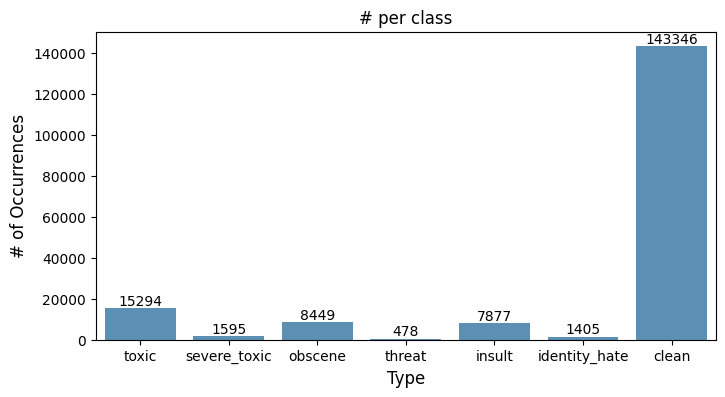

In [15]:

x = train.iloc[:, 2:].sum()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=x.index, y=x.values, alpha=0.8)  # ✅ use x= and y=
plt.title("# per class")
plt.ylabel('# of Occurrences', fontsize=12)
plt.xlabel('Type', fontsize=12)

# adding the text labels
for rect, label in zip(ax.patches, x.values):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, 
            ha='center', va='bottom')

plt.show()

##### Multi-tagging:

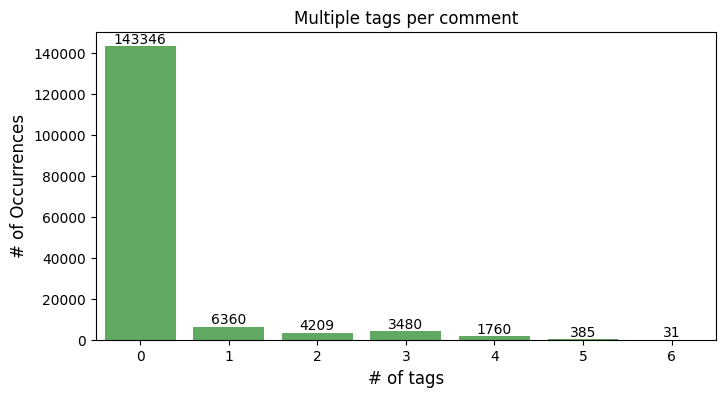

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

x = rowsums.value_counts()
color = sns.color_palette()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=x.index, y=x.values, alpha=0.8, color=color[2])  # ✅ use x= and y=
plt.title("Multiple tags per comment")
plt.ylabel('# of Occurrences', fontsize=12)
plt.xlabel('# of tags', fontsize=12)

# adding the text labels
for rect, label in zip(ax.patches, x.values):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha='center', va='bottom')

plt.show()

**Which tags go together?**

Now let's have a look at how often the tags occur together. A good indicator of that would be a correlation plot.

<Axes: >

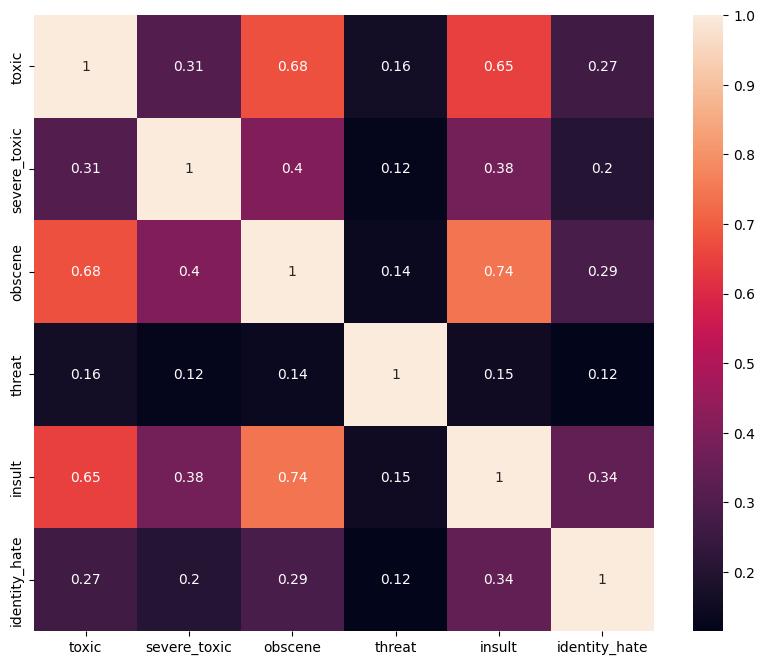

In [17]:


temp_df=train.iloc[:,2:-1]
# filter temp by removing clean comments
# temp_df=temp_df[~train.clean]

corr=temp_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values, annot=True)





The above plot indicates a pattern of co-occurance but Pandas's default Corr function which uses Pearson correlation does not apply here, since the variables invovled are Categorical (binary) variables.

So, to find a pattern between two categorical variables we can use other tools like

- Confusion matrix/Crosstab
- Cramer's V Statistic : 
        Cramer's V stat is an extension of the chi-square test where the extent/strength of association is also measured



In [18]:
def highlight_min(data, color='yellow'):
    '''
    highlight the maximum in a Series or DataFrame
    '''
    attr = 'background-color: {}'.format(color)
    if data.ndim == 1:  # Series from .apply(axis=0) or axis=1
        is_min = data == data.min()
        return [attr if v else '' for v in is_min]
    else:  # from .apply(axis=None)
        is_max = data == data.min().min()
        return pd.DataFrame(np.where(is_min, attr, ''),
                            index=data.index, columns=data.columns)

In [19]:


#Crosstab
# Since technically a crosstab between all 6 classes is impossible to vizualize, lets take a 
# look at toxic with other tags
main_col="toxic"
corr_mats=[]
for other_col in temp_df.columns[1:]:
    confusion_matrix = pd.crosstab(temp_df[main_col], temp_df[other_col])
    corr_mats.append(confusion_matrix)
out = pd.concat(corr_mats,axis=1,keys=temp_df.columns[1:])

#cell highlighting
out = out.style.apply(highlight_min,axis=0)
out



In [20]:
import scipy.stats as ss
#https://stackoverflow.com/questions/20892799/using-pandas-calculate-cram%C3%A9rs-coefficient-matrix/39266194
def cramers_corrected_stat(confusion_matrix):
    """ calculate Cramers V statistic for categorial-categorial association.
        uses correction from Bergsma and Wicher, 
        Journal of the Korean Statistical Society 42 (2013): 323-328
    """
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))






#Checking for Toxic and Severe toxic for now
import pandas as pd
col1="toxic"
col2="severe_toxic"
confusion_matrix = pd.crosstab(temp_df[col1], temp_df[col2])
print("Confusion matrix between toxic and severe toxic:")
print(confusion_matrix)
new_corr=cramers_corrected_stat(confusion_matrix)
print("The correlation between Toxic and Severe toxic using Cramer's stat=",new_corr)



Confusion matrix between toxic and severe toxic:
severe_toxic       0     1
toxic                     
0             144277     0
1              13699  1595
The correlation between Toxic and Severe toxic using Cramer's stat= 0.30850290540548614


## Wordclouds - Frequent words:


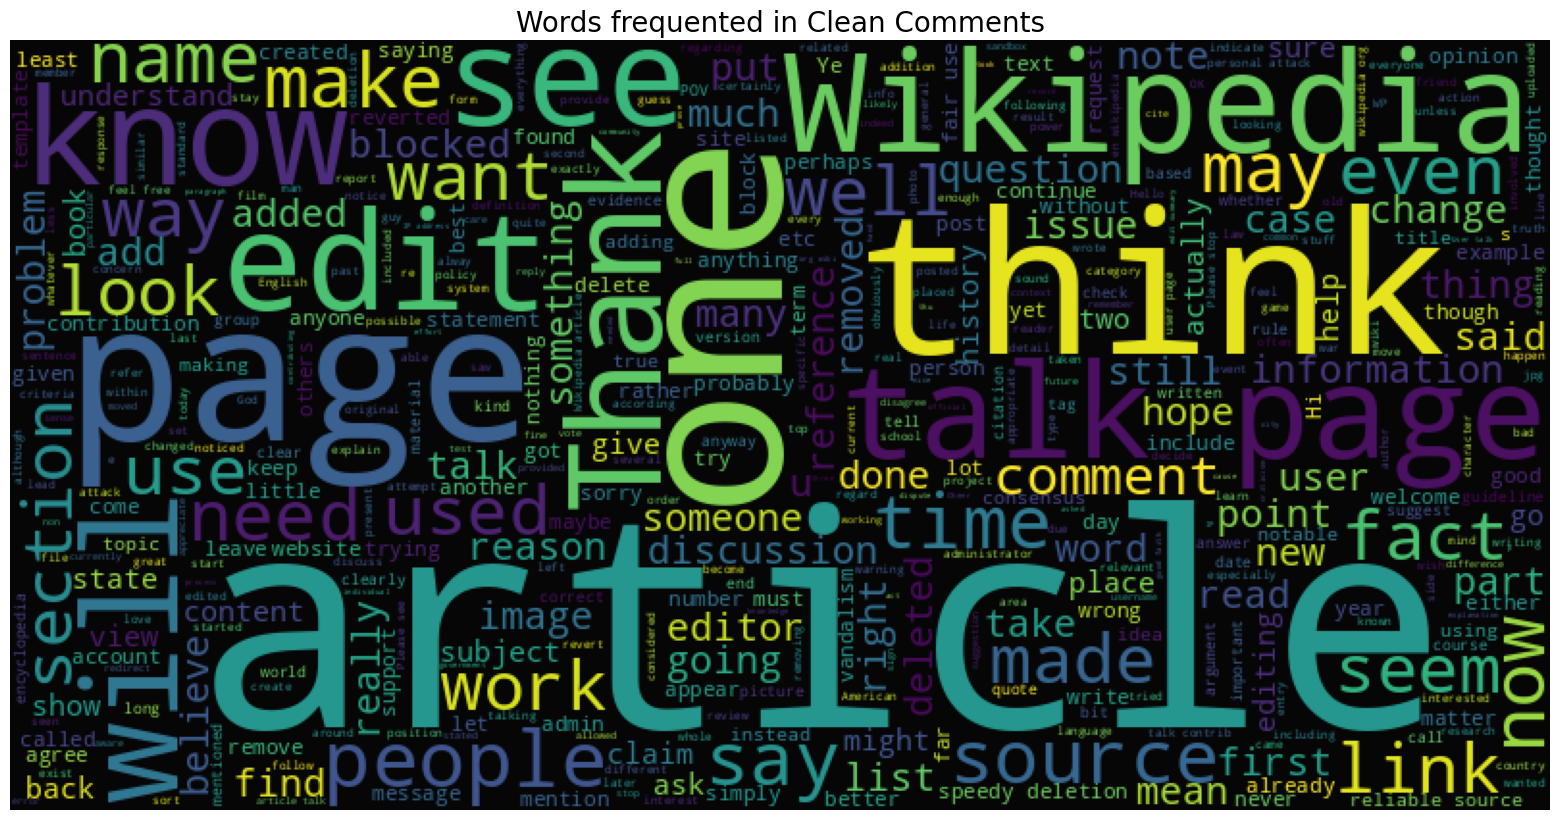

In [21]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# subset of "clean" comments
subset = train[train.clean == True]
text = subset.comment_text.values

wc = WordCloud(
    background_color="black",
    max_words=2000,
    stopwords=STOPWORDS,
    width=800, 
    height=400,  # controls the shape
).generate(" ".join(text))

plt.figure(figsize=(20, 10))
plt.axis("off")
plt.title("Words frequented in Clean Comments", fontsize=20)
plt.imshow(wc.recolor(colormap='viridis', random_state=17), alpha=0.98)
plt.show()

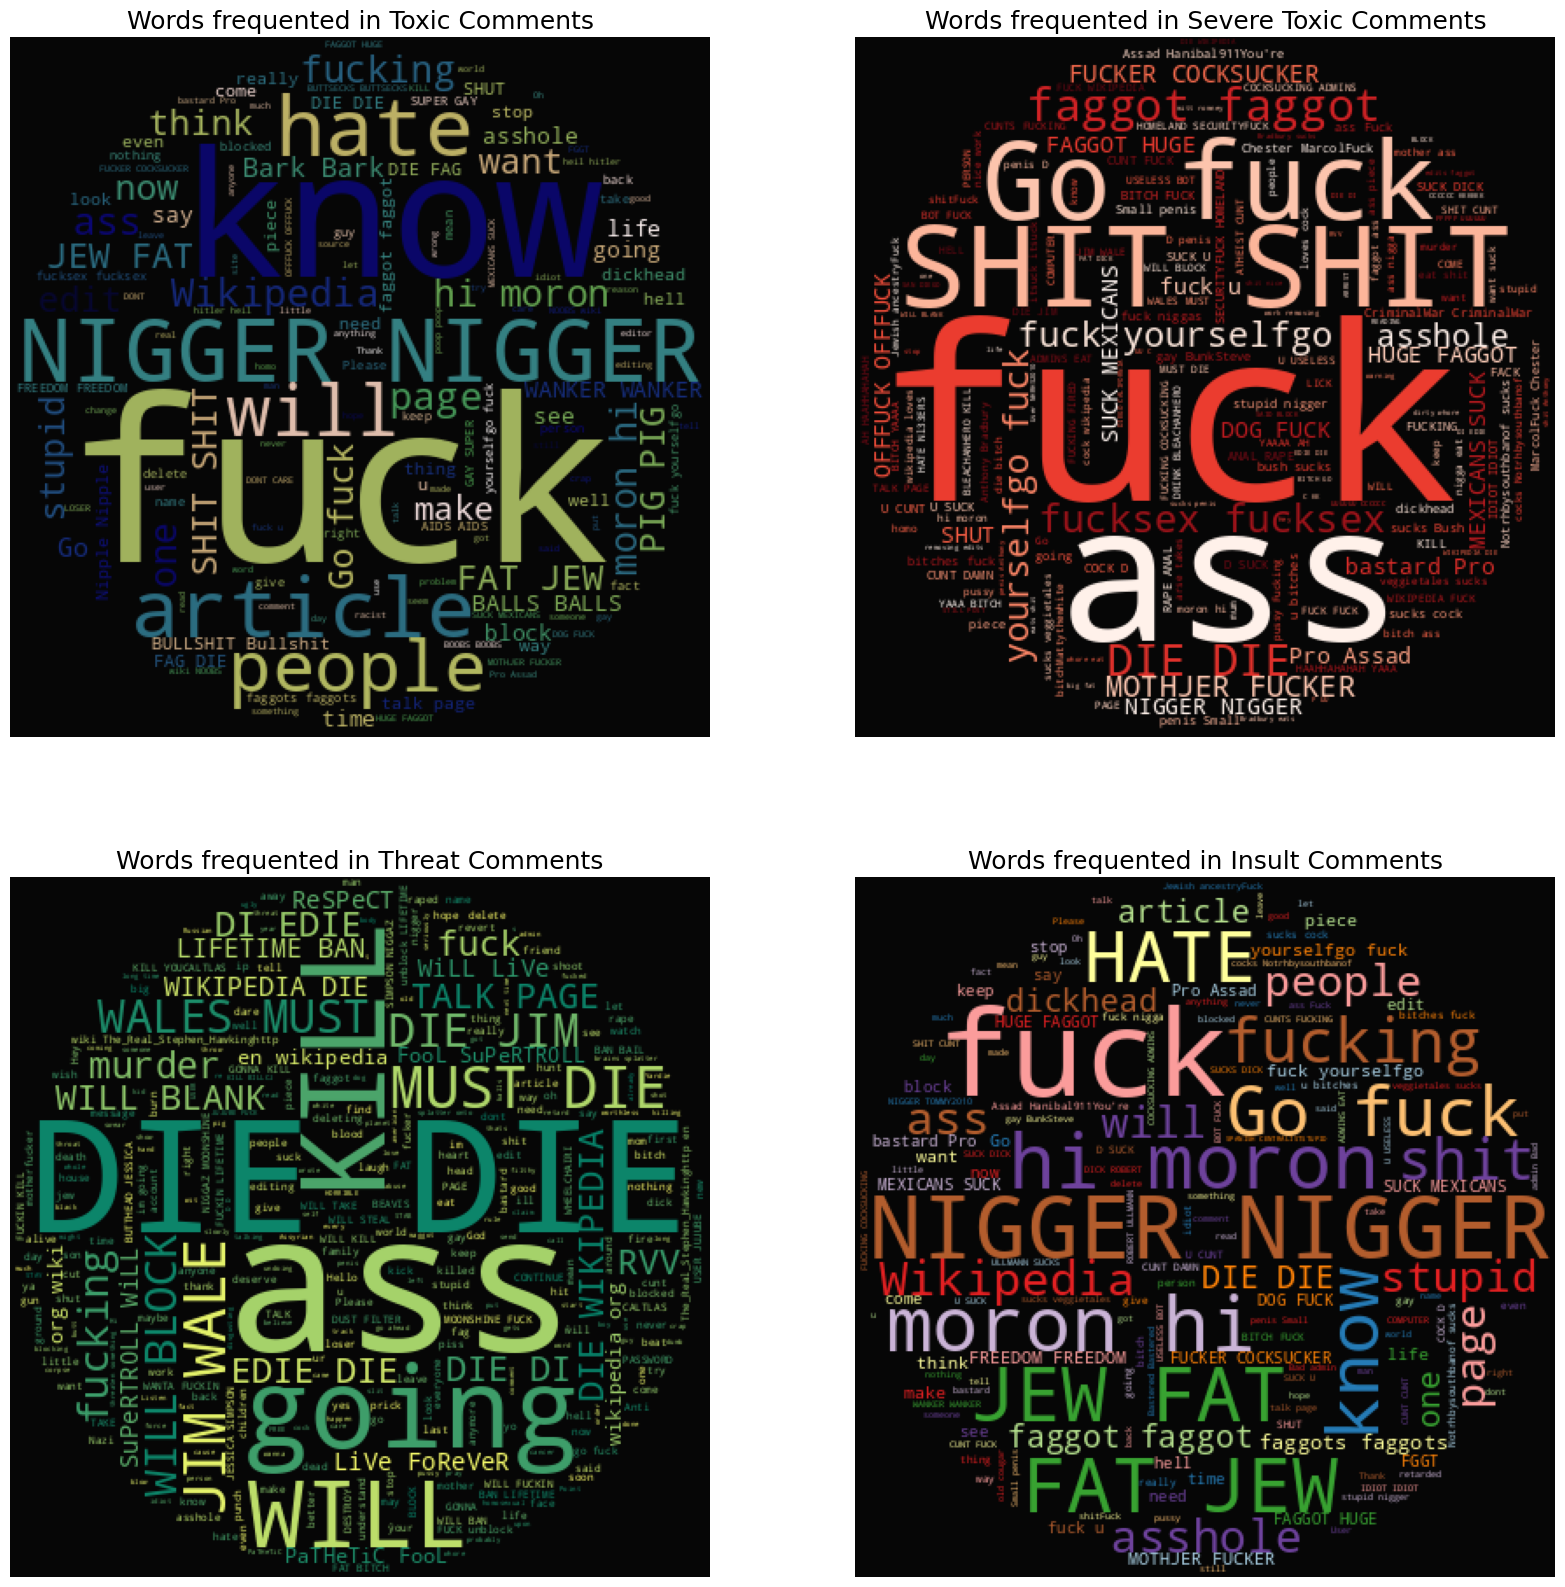

In [22]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

# Example function to create a simple circular mask
def circular_mask(size=400):
    x, y = np.ogrid[:size, :size]
    mask = (x - size//2)**2 + (y - size//2)**2 > (size//2)**2
    return 255 * mask.astype(int)  # WordCloud expects 0/255

# Categories and colormaps
categories = ['toxic', 'severe_toxic', 'threat', 'insult']
colormaps = ['gist_earth', 'Reds', 'summer', 'Paired_r']

plt.figure(figsize=(20, 20))

for i, (cat, cmap) in enumerate(zip(categories, colormaps), 1):
    subset = train[train[cat] == 1]
    text = subset.comment_text.values
    wc = WordCloud(
        background_color='black',
        max_words=2000,
        stopwords=STOPWORDS,
        mask=circular_mask(400)  # simple circle mask
    ).generate(" ".join(text))
    
    plt.subplot(2, 2, i)
    plt.imshow(wc.recolor(colormap=cmap, random_state=42), alpha=0.98)
    plt.axis('off')
    plt.title(f"Words frequented in {cat.replace('_',' ').title()} Comments", fontsize=18)

plt.show()

# Feature engineering:

**Direct features:**

Features which are a directly due to words/content.We would be exploring the following techniques

- Word frequency features
- - Count features
- - Bigrams
- - Trigrams
- Vector distance mapping of words (Eg: Word2Vec)
- Sentiment scores

**Indirect features:**

Some more experimental features.

- count of sentences
- count of words
- count of unique words
- count of letters
- count of punctuations
- count of uppercase words/letters
- count of stop words
- Avg length of each word

**Leaky features:**

From the example, we know that the comments contain identifier information (eg: IP, username,etc.). We can create features out of them but, it will certainly lead to overfitting to this specific Wikipedia use-case.

- toxic IP scores
- toxic users

Note: Creating the indirect and leaky features first. There are two reasons for this,

- Count features(Direct features) are useful only if they are created from a clean corpus
- Also the indirect features help compensate for the loss of information when cleaning the dataset


In [23]:
merge=pd.concat([train.iloc[:,0:2],test.iloc[:,0:2]])
df=merge.reset_index(drop=True)
df

,id,comment_text
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It..."
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ..."
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember..."
...,...,...
312730,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu..."
312731,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...
312732,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ..."
312733,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the..."


**Indirect features**

Sometimes, these features improve model performance because they capture structural and stylistic patterns in text.


In [24]:

#Sentense count in each comment:
    #  '\n' can be used to count the number of sentences in each comment
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
eng_stopwords = set(ENGLISH_STOP_WORDS)

df['count_sent']=df["comment_text"].apply(lambda x: len(re.findall("\n",str(x)))+1)
#Word count in each comment:
df['count_word']=df["comment_text"].apply(lambda x: len(str(x).split()))
#Unique word count
df['count_unique_word']=df["comment_text"].apply(lambda x: len(set(str(x).split())))
#Letter count
df['count_letters']=df["comment_text"].apply(lambda x: len(str(x)))
#punctuation count
df["count_punctuations"] =df["comment_text"].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
#upper case words count
df["count_words_upper"] = df["comment_text"].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))
#title case words count
df["count_words_title"] = df["comment_text"].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))
#Number of stopwords
df["count_stopwords"] = df["comment_text"].apply(lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords]))
#Average length of the words
df["mean_word_len"] = df["comment_text"].apply(lambda x: np.mean([len(w) for w in str(x).split()]))


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [25]:
#derived features
#Word count percent in each comment:
df['word_unique_percent']=df['count_unique_word']*100/df['count_word']
#derived features
#Punct percent in each comment:
df['punct_percent']=df['count_punctuations']*100/df['count_word']

In [26]:
#serperate train and test features
train_feats=df.iloc[0:len(train),]
test_feats=df.iloc[len(train):,]
#join the tags
train_tags=train.iloc[:,2:]
train_feats=pd.concat([train_feats,train_tags],axis=1)

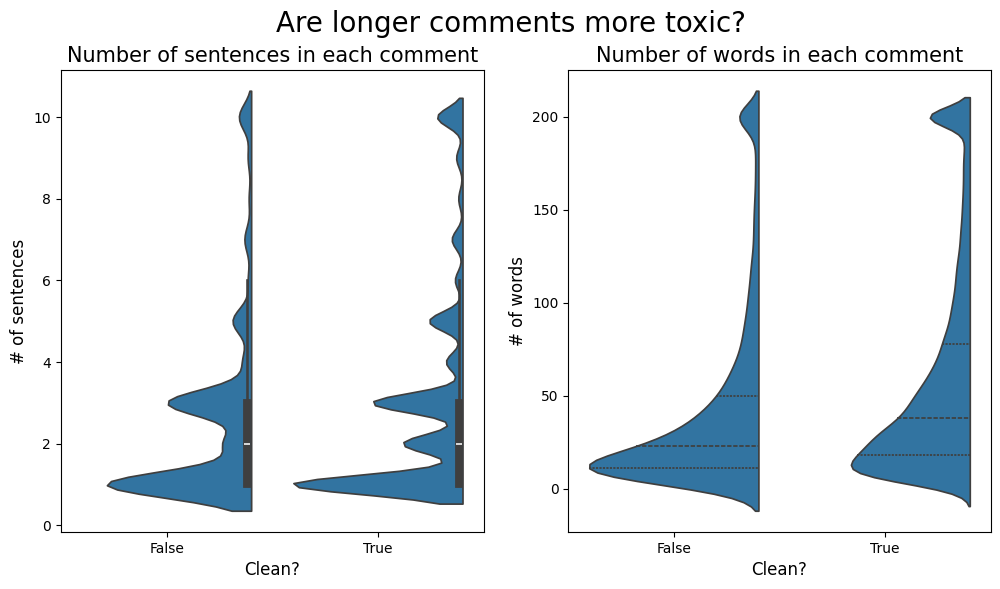

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Clip long comments to avoid extreme values affecting plots
train_feats['count_sent'] = np.clip(train_feats['count_sent'], 0, 10)
train_feats['count_word'] = np.clip(train_feats['count_word'], 0, 200)

plt.figure(figsize=(12,6))
plt.suptitle("Are longer comments more toxic?", fontsize=20)

# Number of sentences
plt.subplot(121)
sns.violinplot(y='count_sent', x='clean', data=train_feats, split=True)
plt.xlabel('Clean?', fontsize=12)
plt.ylabel('# of sentences', fontsize=12)
plt.title("Number of sentences in each comment", fontsize=15)

# Number of words
plt.subplot(122)
sns.violinplot(y='count_word', x='clean', data=train_feats, split=True, inner="quart")
plt.xlabel('Clean?', fontsize=12)
plt.ylabel('# of words', fontsize=12)
plt.title("Number of words in each comment", fontsize=15)

plt.show()

/tmp/ipykernel_1139712/1815795708.py:50: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/tmp/ipykernel_1139712/1815795708.py:57: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/tmp/ipykernel_1139712/1815795708.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


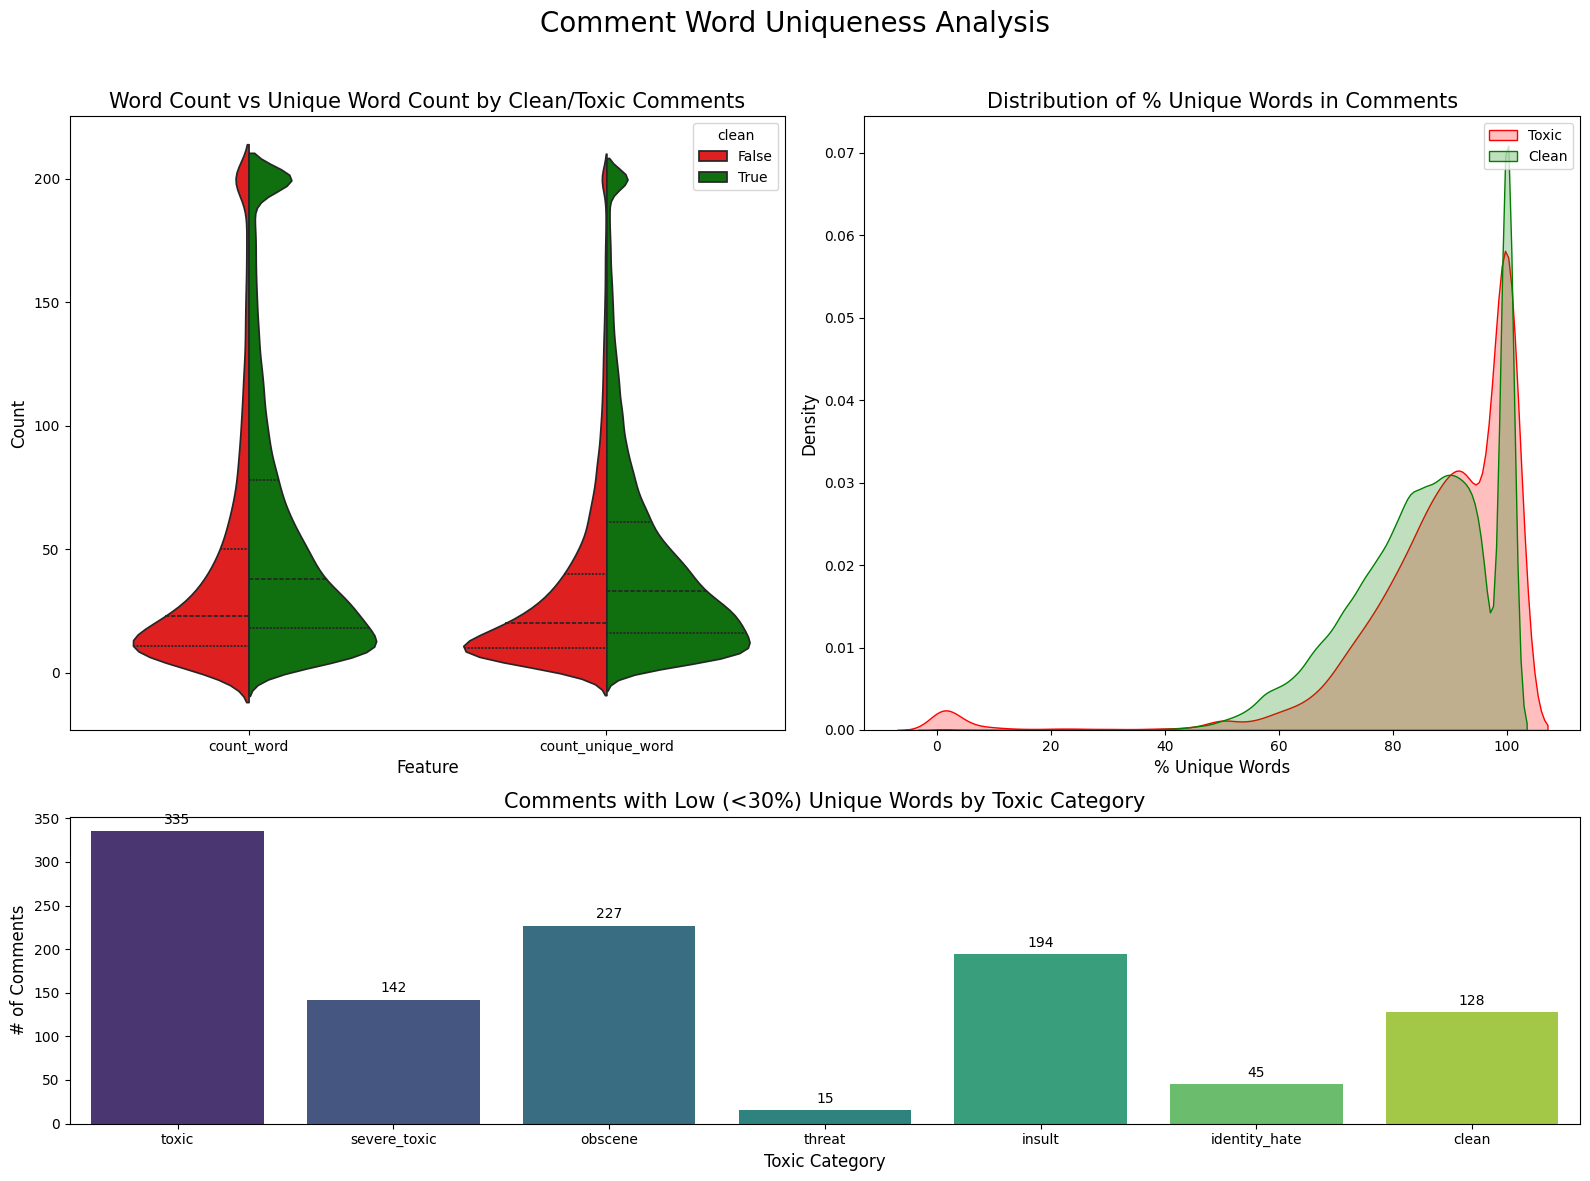

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Clip extreme values to avoid long tails
train_feats['count_unique_word'] = np.clip(train_feats['count_unique_word'], 0, 200)
train_feats['count_word'] = np.clip(train_feats['count_word'], 0, 200)

# Melt for violin plots (long format)
temp_df = pd.melt(
    train_feats, 
    id_vars='clean', 
    value_vars=['count_word', 'count_unique_word'], 
    var_name='feature', 
    value_name='count'
)

# Identify spammers (low unique word %)
spammers = train_feats[train_feats['word_unique_percent'] < 30]
x_spammers = spammers.iloc[:, -7:].sum()  # last 7 toxic categories

# Prepare figure with gridspec
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])
fig.suptitle("Comment Word Uniqueness Analysis", fontsize=20)

# -----------------------------
# Violin plot: absolute counts
# -----------------------------
ax0 = fig.add_subplot(gs[0, 0])
sns.violinplot(
    x='feature',
    y='count',
    hue='clean',
    data=temp_df,
    inner='quartile',
    palette={0:'red', 1:'green'},
    split=True,
    ax=ax0
)
ax0.set_title("Word Count vs Unique Word Count by Clean/Toxic Comments", fontsize=15)
ax0.set_xlabel('Feature', fontsize=12)
ax0.set_ylabel('Count', fontsize=12)

# -----------------------------
# KDE plot: % of unique words
# -----------------------------
ax1 = fig.add_subplot(gs[0, 1])
sns.kdeplot(
    train_feats.loc[train_feats.clean==0, 'word_unique_percent'], 
    label='Toxic', 
    shade=True, 
    color='red',
    ax=ax1
)
sns.kdeplot(
    train_feats.loc[train_feats.clean==1, 'word_unique_percent'], 
    label='Clean', 
    shade=True,
    color='green',
    ax=ax1
)
ax1.set_title("Distribution of % Unique Words in Comments", fontsize=15)
ax1.set_xlabel('% Unique Words', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()

# -----------------------------
# Bar plot: low unique word comments
# -----------------------------
ax2 = fig.add_subplot(gs[1, :])
sns.barplot(
    x=x_spammers.index, 
    y=x_spammers.values, 
    palette='viridis',
    ax=ax2
)
ax2.set_title("Comments with Low (<30%) Unique Words by Toxic Category", fontsize=15)
ax2.set_xlabel('Toxic Category', fontsize=12)
ax2.set_ylabel('# of Comments', fontsize=12)

# Add text labels on top of bars
for rect, label in zip(ax2.patches, x_spammers.values):
    height = rect.get_height()
    ax2.text(
        rect.get_x() + rect.get_width() / 2, 
        height + 5, 
        label, 
        ha='center', 
        va='bottom'
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])  # adjust for suptitle
plt.show()

In [29]:


print("Clean Spam example:")
print(spammers[spammers.clean==1].comment_text.iloc[1])
print("Toxic Spam example:")
print(spammers[spammers.toxic==1].comment_text.iloc[2])



Clean Spam example:
Towns and Villages in Ark-La-Tex]]
 Cities, boroughs and towns in the Republic of Ireland
 Cities, boroughs, and townships along the Susquehanna River
 Cities, towns and villages in Alborz Province
 Cities, towns and villages in Ardabil Province
 Cities, towns and villages in Bhutan
 Cities, towns and villages in Bushehr Province
 Cities, towns and villages in Chaharmahal and Bakhtiari Province
 Cities, towns and villages in Cyprus
 Cities, towns and villages in Dutch Limburg
 Cities, towns and villages in East Azerbaijan Province
 Cities, towns and villages in East Timor
 Cities, towns and villages in Fars Province
 Cities, towns and villages in Flevoland
 Cities, towns and villages in Friesland
 Cities, towns and villages in Gelderland
 Cities, towns and villages in Gilan Province
 Cities, towns and villages in Golestan Province
 Cities, towns and villages in Groningen
 Cities, towns and villages in Hamadan Province
 Cities, towns and villages in Hormozgan Provinc

**Corpus cleaning:**

In [30]:
corpus=merge['comment_text']

In [31]:
# Aphost lookup dict
APPO = {
"aren't" : "are not",
"can't" : "cannot",
"couldn't" : "could not",
"didn't" : "did not",
"doesn't" : "does not",
"don't" : "do not",
"hadn't" : "had not",
"hasn't" : "has not",
"haven't" : "have not",
"he'd" : "he would",
"he'll" : "he will",
"he's" : "he is",
"i'd" : "I would",
"i'd" : "I had",
"i'll" : "I will",
"i'm" : "I am",
"isn't" : "is not",
"it's" : "it is",
"it'll":"it will",
"i've" : "I have",
"let's" : "let us",
"mightn't" : "might not",
"mustn't" : "must not",
"shan't" : "shall not",
"she'd" : "she would",
"she'll" : "she will",
"she's" : "she is",
"shouldn't" : "should not",
"that's" : "that is",
"there's" : "there is",
"they'd" : "they would",
"they'll" : "they will",
"they're" : "they are",
"they've" : "they have",
"we'd" : "we would",
"we're" : "we are",
"weren't" : "were not",
"we've" : "we have",
"what'll" : "what will",
"what're" : "what are",
"what's" : "what is",
"what've" : "what have",
"where's" : "where is",
"who'd" : "who would",
"who'll" : "who will",
"who're" : "who are",
"who's" : "who is",
"who've" : "who have",
"won't" : "will not",
"wouldn't" : "would not",
"you'd" : "you would",
"you'll" : "you will",
"you're" : "you are",
"you've" : "you have",
"'re": " are",
"wasn't": "was not",
"we'll":" will",
"didn't": "did not",
"tryin'":"trying"
}

In [32]:

from nltk.tokenize import TweetTokenizer   
from nltk.stem.wordnet import WordNetLemmatizer 



lem = WordNetLemmatizer()
tokenizer=TweetTokenizer()


def clean(comment):
    """
    This function receives comments and returns clean word-list
    """
    #Convert to lower case , so that Hi and hi are the same
    comment=comment.lower()
    #remove \n
    comment=re.sub("\\n","",comment)
    # remove leaky elements like ip,user
    comment=re.sub("\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}","",comment)
    #removing usernames
    comment=re.sub("\[\[.*\]","",comment)
    
    #Split the sentences into words
    words=tokenizer.tokenize(comment)
    
    # (')aphostophe  replacement (ie)   you're --> you are  
    # ( basic dictionary lookup : master dictionary present in a hidden block of code)
    words=[APPO[word] if word in APPO else word for word in words]
    words=[lem.lemmatize(word, "v") for word in words]
    words = [w for w in words if not w in eng_stopwords]
    
    clean_sent=" ".join(words)
    # remove any non alphanum,digit character
    #clean_sent=re.sub("\W+"," ",clean_sent)
    #clean_sent=re.sub("  "," ",clean_sent)
    return(clean_sent)



In [33]:
corpus.iloc[12235]

'"\n\n NOTE If you read above, and follow the links, any reader can see that I cited correctly the links I added on this subject. Vidkun has added anotations to make them read as the oposite, but these links show the ""official"" line taken by UGLE. I will not be trapped by any User into so-called 3RR, so he can peddle his POV. Strangly, ALL other ""MASONS"" are quiet, leaving ‘‘me’’ to defend that factual truth on my own. ""Thanks"" Brethren. Sitting any blocking out if given...  "'

In [34]:
clean(corpus.iloc[12235])

'" note read , follow link , reader cite correctly link add subject . vidkun add anotations make read oposite , link " " official " " line ugle . trap user so-called 3rr , peddle pov . strangly , " " masons " " quiet , leave ‘ ‘ ’ ’ defend factual truth . " " thank " " brethren . sit block ... "'

In [35]:
clean_corpus=corpus.apply(lambda x :clean(x))

**Direct features:**

### Unigrams -- TF-IDF 

In [36]:
import time


start_unigrams=time.time()
tfv = TfidfVectorizer(min_df=200,  max_features=10000, 
            strip_accents='unicode', analyzer='word',ngram_range=(1,1),
            use_idf=True,smooth_idf=True,sublinear_tf=True,
            stop_words = 'english')
tfv.fit(clean_corpus)
features = np.array(tfv.get_feature_names_out())

train_unigrams =  tfv.transform(clean_corpus.iloc[:train.shape[0]])
test_unigrams = tfv.transform(clean_corpus.iloc[train.shape[0]:])


In [37]:
def top_tfidf_feats(row, features, top_n=25):
    ''' Get top n tfidf values in row and return them with their corresponding feature names.'''
    topn_ids = np.argsort(row)[::-1][:top_n]
    top_feats = [(features[i], row[i]) for i in topn_ids]
    df = pd.DataFrame(top_feats)
    df.columns = ['feature', 'tfidf']
    return df

def top_feats_in_doc(Xtr, features, row_id, top_n=25):
    ''' Top tfidf features in specific document (matrix row) '''
    row = np.squeeze(Xtr[row_id].toarray())
    return top_tfidf_feats(row, features, top_n)

def top_mean_feats(Xtr, features, grp_ids, min_tfidf=0.1, top_n=25):
    ''' Return the top n features that on average are most important amongst documents in rows
        indentified by indices in grp_ids. '''
    
    D = Xtr[grp_ids].toarray()

    D[D < min_tfidf] = 0
    tfidf_means = np.mean(D, axis=0)
    return top_tfidf_feats(tfidf_means, features, top_n)

# modified for multilabel milticlass
def top_feats_by_class(Xtr, features, min_tfidf=0.1, top_n=20):
    ''' Return a list of dfs, where each df holds top_n features and their mean tfidf value
        calculated across documents with the same class label. '''
    dfs = []
    cols=train_tags.columns
    for col in cols:
        ids = train_tags.index[train_tags[col]==1]
        feats_df = top_mean_feats(Xtr, features, ids, min_tfidf=min_tfidf, top_n=top_n)
        feats_df.label = label
        dfs.append(feats_df)
    return dfs


In [38]:
#get top n for unigrams
tfidf_top_n_per_lass=top_feats_by_class(train_unigrams,features)

end_unigrams=time.time()

print("total time in unigrams",end_unigrams-start_unigrams)
# print("total time till unigrams",end_unigrams-start_time)

total time in unigrams 47.53058934211731


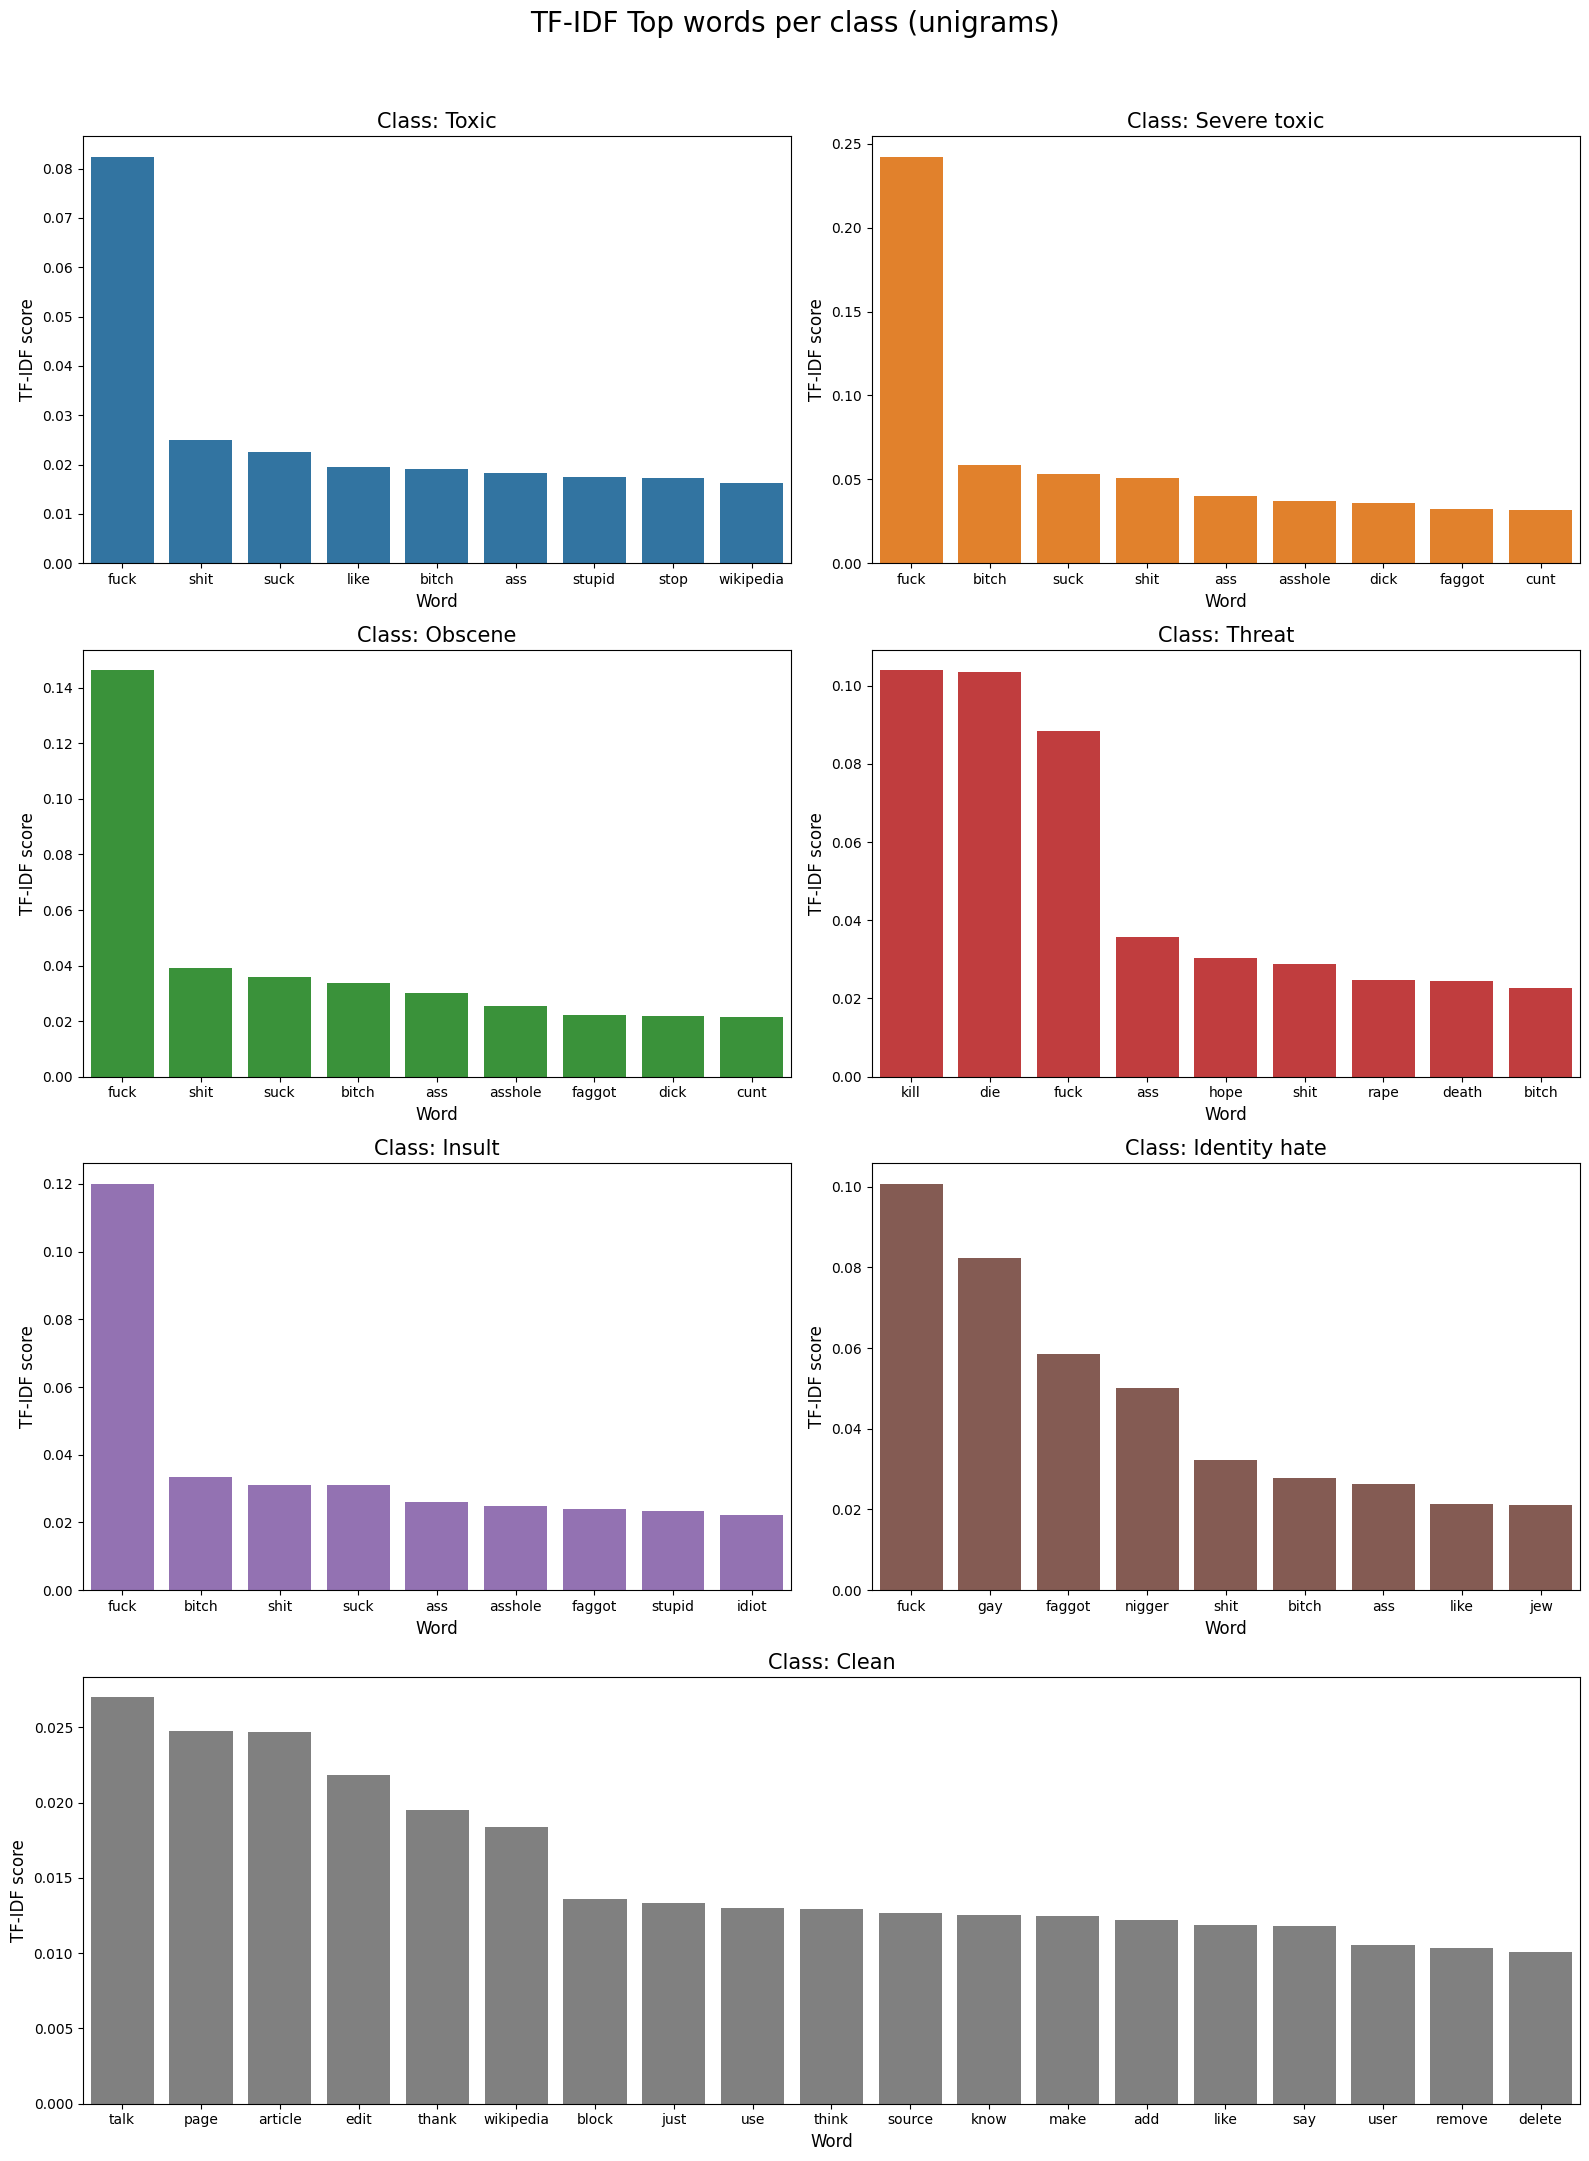

In [39]:
plt.figure(figsize=(16,22))
plt.suptitle("TF-IDF Top words per class (unigrams)", fontsize=20)

plt.subplot2grid((4,2),(0,0))
sns.barplot(
    x=tfidf_top_n_per_lass[0].feature.iloc[0:9],
    y=tfidf_top_n_per_lass[0].tfidf.iloc[0:9],
    color=color[0]
)
plt.title("Class: Toxic", fontsize=15)
plt.xlabel('Word', fontsize=12)
plt.ylabel('TF-IDF score', fontsize=12)

plt.subplot2grid((4,2),(0,1))
sns.barplot(
    x=tfidf_top_n_per_lass[1].feature.iloc[0:9],
    y=tfidf_top_n_per_lass[1].tfidf.iloc[0:9],
    color=color[1]
)
plt.title("Class: Severe toxic", fontsize=15)
plt.xlabel('Word', fontsize=12)
plt.ylabel('TF-IDF score', fontsize=12)

plt.subplot2grid((4,2),(1,0))
sns.barplot(
    x=tfidf_top_n_per_lass[2].feature.iloc[0:9],
    y=tfidf_top_n_per_lass[2].tfidf.iloc[0:9],
    color=color[2]
)
plt.title("Class: Obscene", fontsize=15)
plt.xlabel('Word', fontsize=12)
plt.ylabel('TF-IDF score', fontsize=12)

plt.subplot2grid((4,2),(1,1))
sns.barplot(
    x=tfidf_top_n_per_lass[3].feature.iloc[0:9],
    y=tfidf_top_n_per_lass[3].tfidf.iloc[0:9],
    color=color[3]
)
plt.title("Class: Threat", fontsize=15)
plt.xlabel('Word', fontsize=12)
plt.ylabel('TF-IDF score', fontsize=12)

plt.subplot2grid((4,2),(2,0))
sns.barplot(
    x=tfidf_top_n_per_lass[4].feature.iloc[0:9],
    y=tfidf_top_n_per_lass[4].tfidf.iloc[0:9],
    color=color[4]
)
plt.title("Class: Insult", fontsize=15)
plt.xlabel('Word', fontsize=12)
plt.ylabel('TF-IDF score', fontsize=12)

plt.subplot2grid((4,2),(2,1))
sns.barplot(
    x=tfidf_top_n_per_lass[5].feature.iloc[0:9],
    y=tfidf_top_n_per_lass[5].tfidf.iloc[0:9],
    color=color[5]
)
plt.title("Class: Identity hate", fontsize=15)
plt.xlabel('Word', fontsize=12)
plt.ylabel('TF-IDF score', fontsize=12)

plt.subplot2grid((4,2),(3,0), colspan=2)
sns.barplot(
    x=tfidf_top_n_per_lass[6].feature.iloc[0:19],
    y=tfidf_top_n_per_lass[6].tfidf.iloc[0:19],
    color='gray'
)
plt.title("Class: Clean", fontsize=15)
plt.xlabel('Word', fontsize=12)
plt.ylabel('TF-IDF score', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [40]:
p

NameError: name 'p' is not defined

In [12]:
lens = train['comment_text'].str.len()
lens.mean(), lens.std(), lens.max()

(394.0732213246768, 590.7202819048919, 5000)

<Axes: >

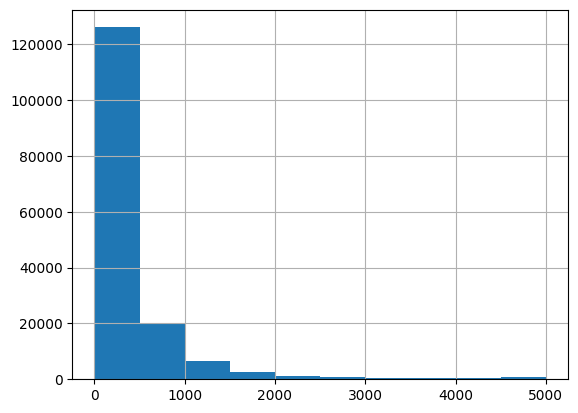

In [13]:
lens.hist()

In [14]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
train['none'] = 1-train[label_cols].max(axis=1)
train.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate,none
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805,0.898321
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420,0.302226
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# NB-SVM

In [15]:
COMMENT = 'comment_text'
train.fillna({COMMENT: "unknown"}, inplace=True)
test.fillna({COMMENT: "unknown"}, inplace=True)


In [16]:
import re, string

re_tok = re.compile(f'([{string.punctuation}“”¨«»®´·º½¾¿¡§£₤‘’])')
def tokenize(s): return re_tok.sub(r' \1 ', s).split()


In [8]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from scipy import sparse

# -----------------------------
# TF-IDF (word-level)
# -----------------------------
word_vec = TfidfVectorizer(
    ngram_range=(1, 2),
    tokenizer=tokenize,
    token_pattern=None,
    min_df=5,
    max_df=0.9,
    strip_accents='unicode',
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True
)

trn_word = word_vec.fit_transform(train[COMMENT])
test_word = word_vec.transform(test[COMMENT])

# -----------------------------
# TF-IDF (char-level) 🔥
# -----------------------------
# char_vec = TfidfVectorizer(
#     analyzer='char',
#     ngram_range=(3, 4),
#     min_df=3,
#     max_df=0.9,
#     sublinear_tf=True
# )

# trn_char = char_vec.fit_transform(train[COMMENT])
# test_char = char_vec.transform(test[COMMENT])

# Combine features
x = sparse.hstack([trn_word]).tocsr()
test_x = sparse.hstack([test_word]).tocsr()

In [9]:


# -----------------------------
# NB log-count ratio
# -----------------------------
def pr(y_i, y):
    p = x[y == y_i].sum(0)
    return (p + 1) / ((y == y_i).sum() + 1)

# -----------------------------
# Model function
# -----------------------------
def get_mdl(y):
    y = y.values
    
    r = np.log(pr(1, y) / pr(0, y))
    x_nb = x.multiply(r)
    
    model = LogisticRegression(
        C=4,
        solver='liblinear',
        dual=True,
        max_iter=1000,
        n_jobs=-1
    )
    
    return model.fit(x_nb, y), r

# -----------------------------
# Cross-validation (OOF)
# -----------------------------
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros((len(train), len(label_cols)))
test_preds = np.zeros((len(test), len(label_cols)))

for i, col in enumerate(label_cols):
    print(f"\nTraining label: {col}")
    
    y = train[col].values
    test_pred_col = np.zeros(len(test))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(x, y)):
        print(f"  Fold {fold+1}")
        
        x_tr, x_val = x[tr_idx], x[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        
        # recompute NB weights per fold
        def pr_fold(y_i, y_local):
            p = x_tr[y_local == y_i].sum(0)
            return (p + 1) / ((y_local == y_i).sum() + 1)
        
        r = np.log(pr_fold(1, y_tr) / pr_fold(0, y_tr))
        
        x_tr_nb = x_tr.multiply(r)
        x_val_nb = x_val.multiply(r)
        test_nb = test_x.multiply(r)
        
        model = LogisticRegression(
            C=4,
            solver='liblinear', # 
            dual=True, # True
            max_iter=1000,
            n_jobs=-1
        )
        
        model.fit(x_tr_nb, y_tr)
        
        oof_preds[val_idx, i] = model.predict_proba(x_val_nb)[:, 1]
        test_pred_col += model.predict_proba(test_nb)[:, 1] / n_splits
    
    test_preds[:, i] = test_pred_col

# -----------------------------
# Submission
# -----------------------------
submission = pd.DataFrame({
    'id': subm["id"]
})

submission = pd.concat(
    [submission, pd.DataFrame(test_preds, columns=label_cols)],
    axis=1
)

submission.to_csv("submission.csv", index=False)


Training label: toxic
  Fold 1


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


  Fold 2


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


  Fold 3


...

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


  Fold 2


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


  Fold 3


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
